# LSTM Model — Stock Return Prediction & Ranking (15 Stocks)

## Objective
Build an LSTM model to predict weekly stock return **direction** (up/down) for 15 stocks across sectors and rank them for portfolio allocation.

**Stocks:** AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA, JPM, GS, JNJ, PFE, XOM, CVX, WMT, BA

**Approach:** Binary classification (up vs down).

**Architecture:** LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(16, ReLU) → BatchNorm → Dense(1, sigmoid).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, f1_score

tf.random.set_seed(42)
np.random.seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

print('All imports successful.')

All imports successful.


## 2. Configuration

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'WMT', 'BA']
SEQUENCE_LENGTH = 4
EPOCHS = 200
BATCH_SIZE = 32
PATIENCE = 20
OUT_DIR = '../../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

COLORS = {
    'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c',
    'AMZN': '#d62728', 'NVDA': '#9467bd', 'META': '#8c564b',
    'TSLA': '#e377c2', 'JPM': '#7f7f7f', 'GS': '#bcbd22',
    'JNJ': '#17becf', 'PFE': '#aec7e8', 'XOM': '#ffbb78',
    'CVX': '#98df8a', 'WMT': '#ff9896', 'BA': '#c5b0d5'
}

FILES = {
    'AAPL': '../../data/Apple.csv',
    'MSFT': '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN': '../../data/Amazon.csv',
    'NVDA': '../../data/NVIDIA.csv',
    'META': '../../data/META.csv',
    'TSLA': '../../data/TSLA.csv',
    'JPM': '../../data/JPM.csv',
    'GS': '../../data/GSach.csv',
    'JNJ': '../../data/JNJ.csv',
    'PFE': '../../data/PFE.csv',
    'XOM': '../../data/XOM.csv',
    'CVX': '../../data/CVX.csv',
    'WMT': '../../data/WMT.csv',
    'BA': '../../data/BA.csv',
}

print('Configuration set.')
print(f'  Stocks: {len(TICKERS)}')
print(f'  Sequence length: {SEQUENCE_LENGTH} weeks')
print(f'  Max epochs: {EPOCHS}')
print(f'  Early stopping patience: {PATIENCE}')

Configuration set.
  Stocks: 15
  Sequence length: 4 weeks
  Max epochs: 200
  Early stopping patience: 20


## 3. Load Raw Data & Engineer Features

In [3]:
frames = []
for ticker, path in FILES.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    for col in ['Open', 'High', 'Low', 'Close']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace(',', ''), errors='coerce')
    df = df.sort_values('Date').dropna().reset_index(drop=True)

    df = df.set_index('Date')
    w = pd.DataFrame()
    w['Close'] = df['Close'].resample('W-FRI').last()
    w['High'] = df['High'].resample('W-FRI').max()
    w['Low'] = df['Low'].resample('W-FRI').min()
    w['Open'] = df['Open'].resample('W-FRI').first()
    w['Volume'] = df['Volume'].resample('W-FRI').sum()

    w['Weekly_Return'] = w['Close'].pct_change() * 100
    w['ret_2w'] = w['Close'].pct_change(2) * 100
    w['ret_4w'] = w['Close'].pct_change(4) * 100
    w['ret_8w'] = w['Close'].pct_change(8) * 100

    delta = w['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    w['rsi_14'] = (100 - (100 / (1 + rs))) / 100

    ema12 = w['Close'].ewm(span=12).mean()
    ema26 = w['Close'].ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    w['macd_hist'] = (macd - signal) / w['Close']

    bb_mid = w['Close'].rolling(20).mean()
    bb_std = w['Close'].rolling(20).std()
    w['bb_pct'] = (w['Close'] - bb_mid) / (2 * bb_std.replace(0, np.nan))
    w['bb_width'] = (4 * bb_std) / bb_mid.replace(0, np.nan)

    w['vol_4w'] = w['Weekly_Return'].rolling(4).std()
    w['vol_8w'] = w['Weekly_Return'].rolling(8).std()

    w['price_to_sma5'] = w['Close'] / w['Close'].rolling(5).mean() - 1
    w['price_to_sma20'] = w['Close'] / w['Close'].rolling(20).mean() - 1

    tr = pd.concat([
        w['High'] - w['Low'],
        (w['High'] - w['Close'].shift(1)).abs(),
        (w['Low'] - w['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    w['atr_pct'] = tr.rolling(14).mean() / w['Close']

    w['vol_ratio'] = w['Volume'] / w['Volume'].rolling(10).mean().replace(0, np.nan)
    w['ret_lag1'] = w['Weekly_Return'].shift(1)
    w['ret_lag2'] = w['Weekly_Return'].shift(2)

    w['Ticker'] = ticker
    w = w.dropna().reset_index()
    frames.append(w)
    print(f'{ticker}: {len(w)} weeks, {w["Date"].min().date()} to {w["Date"].max().date()}, {w.shape[1]-2} features')

raw = pd.concat(frames).sort_values(['Date', 'Ticker']).reset_index(drop=True)

for feat in ['Weekly_Return', 'vol_4w', 'rsi_14']:
    cross = raw.pivot_table(index='Date', columns='Ticker', values=feat)
    cs_rank = cross.rank(axis=1, pct=True)
    cs_mean = cross.mean(axis=1)
    cs_std = cross.std(axis=1).replace(0, np.nan)
    cs_z = cross.sub(cs_mean, axis=0).div(cs_std, axis=0)

    for ticker in TICKERS:
        mask = raw['Ticker'] == ticker
        dates = raw.loc[mask, 'Date']
        raw.loc[mask, f'cs_rank_{feat}'] = cs_rank[ticker].reindex(dates.values).values
        raw.loc[mask, f'cs_z_{feat}'] = cs_z[ticker].reindex(dates.values).values

raw = raw.dropna().reset_index(drop=True)

train = raw[raw['Date'] <= '2021-12-31'].copy()
val   = raw[(raw['Date'] >= '2022-01-01') & (raw['Date'] <= '2023-12-31')].copy()
test  = raw[raw['Date'] >= '2024-01-01'].copy()

print(f'\nTotal data: {len(raw)} rows')
print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print(f'Date range: {raw["Date"].min().date()} to {raw["Date"].max().date()}')
print(f'\nClass balance (% weeks with positive return):')
for ticker in TICKERS:
    t = train[train['Ticker'] == ticker]
    up_pct = (t['Weekly_Return'] > 0).mean()
    print(f'  {ticker}: {up_pct:.1%} up / {1-up_pct:.1%} down')

print(f'\nFeatures per stock: {len([c for c in raw.columns if c not in ["Date","Ticker","Close","High","Low","Open","Volume"]])}')

AAPL: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
MSFT: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
GOOGL: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
AMZN: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
NVDA: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
META: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
TSLA: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
JPM: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
GS: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
JNJ: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
PFE: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
XOM: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
CVX: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
WMT: 564 weeks, 2015-05-15 to 2026-02-27, 21 features
BA: 564 weeks, 2015-05-15 to 2026-02-27, 21 features

Total data: 8460 rows
Train: 5205 | Val: 1560 | Test: 1695
Date range: 2015-05-15 to 2026-02-27

Class balance (% weeks with positive return):
  AAPL: 60.2% up / 39.8% down
  MSFT: 61

## 4. Sequence Creation & Model Architecture

In [4]:
feature_cols = [
    'Weekly_Return', 'ret_2w', 'ret_4w', 'ret_8w',
    'rsi_14', 'macd_hist', 'bb_pct', 'bb_width',
    'vol_4w', 'vol_8w', 'price_to_sma5', 'price_to_sma20',
    'atr_pct', 'vol_ratio', 'ret_lag1', 'ret_lag2',
    'cs_rank_Weekly_Return', 'cs_z_Weekly_Return',
    'cs_rank_vol_4w', 'cs_z_vol_4w',
    'cs_rank_rsi_14', 'cs_z_rsi_14'
]

print(f'Features ({len(feature_cols)}):')
for i, f in enumerate(feature_cols):
    print(f'  {i+1:2d}. {f}')

def make_sequences(df, feature_cols, seq_len=SEQUENCE_LENGTH):
    features = df[feature_cols].values
    ret = df['Weekly_Return'].values
    dates = df['Date'].values
    X, y, d = [], [], []
    for i in range(seq_len, len(df)):
        X.append(features[i-seq_len:i])
        y.append(1.0 if ret[i] > 0 else 0.0)
        d.append(dates[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(d)

def build_model(n_features):
    model = Sequential([
        LSTM(64, input_shape=(SEQUENCE_LENGTH, n_features), return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

sample = build_model(len(feature_cols))
sample.summary()

Features (22):
   1. Weekly_Return
   2. ret_2w
   3. ret_4w
   4. ret_8w
   5. rsi_14
   6. macd_hist
   7. bb_pct
   8. bb_width
   9. vol_4w
  10. vol_8w
  11. price_to_sma5
  12. price_to_sma20
  13. atr_pct
  14. vol_ratio
  15. ret_lag1
  16. ret_lag2
  17. cs_rank_Weekly_Return
  18. cs_z_Weekly_Return
  19. cs_rank_vol_4w
  20. cs_z_vol_4w
  21. cs_rank_rsi_14
  22. cs_z_rsi_14


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 64)          │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,297 (137.88 KB)

 Trainable params: 35,265 (137.75 KB)

 Non-trainable params: 32 (128.00 B)

## 5. Train LSTM for All 15 Stocks

This cell takes ~15-20 minutes.

In [5]:
all_predictions = []
all_histories = {}
all_metrics = {}

for ticker in TICKERS:
    print(f'\n{"="*55}')
    print(f'  Training LSTM for {ticker}')
    print(f'{"="*55}')
    
    tf.random.set_seed(42)
    np.random.seed(42)
    
    tr = train[train['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
    va = val[val['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
    te = test[test['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
    
    X_tr, y_tr, d_tr = make_sequences(tr, feature_cols)
    X_va, y_va, d_va = make_sequences(va, feature_cols)
    X_te, y_te, d_te = make_sequences(te, feature_cols)
    
    print(f'  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}')
    print(f'  Class balance: {y_tr.mean():.1%} up | test: {y_te.mean():.1%} up')
    
    model = build_model(len(feature_cols))
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=7, min_lr=1e-6, verbose=0)
        ],
        verbose=0
    )
    
    stopped = len(history.history['loss'])
    all_histories[ticker] = history
    
    probs = model.predict(X_te, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)
    acc = np.mean(preds == y_te)
    f1 = f1_score(y_te, preds)
    
    print(f'  Epochs: {stopped} | Accuracy: {acc:.2%} | F1: {f1:.4f}')
    print(f'  Prob range: [{probs.min():.3f} - {probs.max():.3f}], std: {probs.std():.3f}')
    print(f'  Preds: {preds.sum():.0f} up / {len(preds)-preds.sum():.0f} down')
    
    all_metrics[ticker] = {
        'Directional Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4),
        'Prob Std': round(probs.std(), 4),
        'Preds Up': int(preds.sum()),
        'Preds Down': int(len(preds) - preds.sum()),
        'Stopped Epoch': stopped,
        'Test Samples': len(y_te)
    }
    
    raw_ret = te['Weekly_Return'].values[SEQUENCE_LENGTH:]
    for i in range(len(probs)):
        all_predictions.append({
            'Date': pd.Timestamp(d_te[i]),
            'Ticker': ticker,
            'Predicted_Return': float(probs[i]),
            'Actual_Return': float(raw_ret[i]),
            'Pred_Direction': int(preds[i]),
            'Actual_Direction': int(y_te[i])
        })

print('\n' + '='*55)
print('  RESULTS SUMMARY')
print('='*55)
for t, m in all_metrics.items():
    print(f'  {t}: Acc={m["Directional Accuracy"]:.1%}  F1={m["F1 Score"]:.4f}  |  std: {m["Prob Std"]:.3f}  |  {m["Preds Up"]} up / {m["Preds Down"]} down')


  Training LSTM for AAPL
  Train: 343 | Val: 100 | Test: 109
  Class balance: 60.3% up | test: 53.2% up
  Epochs: 22 | Accuracy: 53.21% | F1: 0.6946
  Prob range: [0.512 - 0.581], std: 0.015
  Preds: 109 up / 0 down

  Training LSTM for MSFT
  Train: 343 | Val: 100 | Test: 109
  Class balance: 61.8% up | test: 53.2% up
  Epochs: 21 | Accuracy: 51.38% | F1: 0.6443
  Prob range: [0.479 - 0.534], std: 0.010
  Preds: 91 up / 18 down

  Training LSTM for GOOGL
  Train: 343 | Val: 100 | Test: 109
  Class balance: 57.7% up | test: 60.6% up
  Epochs: 22 | Accuracy: 58.72% | F1: 0.6667
  Prob range: [0.450 - 0.551], std: 0.022
  Preds: 69 up / 40 down

  Training LSTM for AMZN
  Train: 343 | Val: 100 | Test: 109
  Class balance: 59.2% up | test: 52.3% up
  Epochs: 22 | Accuracy: 52.29% | F1: 0.6829
  Prob range: [0.480 - 0.562], std: 0.014
  Preds: 107 up / 2 down

  Training LSTM for NVDA
  Train: 343 | Val: 100 | Test: 109
  Class balance: 59.2% up | test: 61.5% up
  Epochs: 30 | Accuracy: 5

## 6. Save Predictions

In [6]:
pred_df = pd.DataFrame(all_predictions)
pred_df = pred_df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

pred_df[['Date', 'Ticker', 'Predicted_Return']].to_csv(
    f'{OUT_DIR}/lstm_15stocks_predictions.csv', index=False
)

print(f'Saved: {OUT_DIR}/lstm_15stocks_predictions.csv')
print(f'Shape: {pred_df.shape}')
pred_df.head(15)

Saved: ../../data/results/lstm_15stocks_predictions.csv
Shape: (1635, 6)


,Date,Ticker,Predicted_Return,Actual_Return,Pred_Direction,Actual_Direction
0,2024-02-02,AAPL,0.539620,-3.414406,1,0
1,2024-02-02,AMZN,0.520333,7.975113,1,1
2,2024-02-02,BA,0.522925,1.902954,1,1
3,2024-02-02,CVX,0.496160,2.078584,0,1
4,2024-02-02,GOOGL,0.510160,-6.445890,1,0
5,2024-02-02,GS,0.451478,2.665502,0,1
6,2024-02-02,JNJ,0.485967,-1.811912,0,0
7,2024-02-02,JPM,0.526638,1.422104,1,1
8,2024-02-02,META,0.529750,20.513016,1,1
9,2024-02-02,MSFT,0.514673,1.804768,1,1


## 7. Weekly Stock Rankings

In [7]:
pivot_pred = pred_df.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')
pivot_actual = pred_df.pivot_table(index='Date', columns='Ticker', values='Actual_Return')

predicted_ranks = pivot_pred.rank(axis=1, ascending=False).astype(int)
actual_ranks = pivot_actual.rank(axis=1, ascending=False).astype(int)

n = len(TICKERS)
overall_rank_acc = (predicted_ranks == actual_ranks).values.mean()
print(f'Overall ranking accuracy: {overall_rank_acc:.1%}  (random: {1/n:.1%})')

pred_top1 = pivot_pred.idxmax(axis=1)
actual_top1 = pivot_actual.idxmax(axis=1)
top1_acc = (pred_top1 == actual_top1).mean()
print(f'Top-1 accuracy (best stock): {top1_acc:.1%}  (random: {1/n:.1%})')

top2_acc_list = []
for date in pivot_pred.index:
    pred_top2 = pivot_pred.loc[date].nlargest(2).index.tolist()
    actual_best = pivot_actual.loc[date].idxmax()
    top2_acc_list.append(actual_best in pred_top2)
top2_acc = np.mean(top2_acc_list)
print(f'Top-2 accuracy (best in top 2): {top2_acc:.1%}  (random: {2/n:.1%})')

rankings_df = predicted_ranks.copy()
rankings_df.columns = [f'Rank_{t}' for t in rankings_df.columns]
rankings_df.to_csv(f'{OUT_DIR}/lstm_15stocks_rankings.csv')
print(f'\nSaved: {OUT_DIR}/lstm_15stocks_rankings.csv')

Overall ranking accuracy: 7.1%  (random: 6.7%)
Top-1 accuracy (best stock): 12.8%  (random: 6.7%)
Top-2 accuracy (best in top 2): 19.3%  (random: 13.3%)

Saved: ../../data/results/lstm_15stocks_rankings.csv


## 8. Final Metrics Summary

In [8]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = 'Ticker'

overall_f1 = f1_score(pred_df['Actual_Direction'], pred_df['Pred_Direction'])

print('=' * 70)
print('  LSTM 15-STOCK MODEL — FINAL METRICS')
print('=' * 70)
print(metrics_df.to_string())
print(f'\nOverall F1:               {overall_f1:.4f}')
print(f'Overall ranking accuracy: {overall_rank_acc:.1%}  (random: {1/n:.1%})')
print(f'Top-1 accuracy:           {top1_acc:.1%}  (random: {1/n:.1%})')
print(f'Top-2 accuracy:           {top2_acc:.1%}  (random: {2/n:.1%})')

metrics_df

  LSTM 15-STOCK MODEL — FINAL METRICS
        Directional Accuracy  F1 Score  Prob Std  Preds Up  Preds Down  Stopped Epoch  Test Samples
Ticker                                                                                             
AAPL                  0.5321    0.6946    0.0146     109.0         0.0           22.0         109.0
MSFT                  0.5138    0.6443    0.0096      91.0        18.0           21.0         109.0
GOOGL                 0.5872    0.6667    0.0221      69.0        40.0           22.0         109.0
AMZN                  0.5229    0.6829    0.0136     107.0         2.0           22.0         109.0
NVDA                  0.5138    0.6294    0.0392      76.0        33.0           30.0         109.0
META                  0.5229    0.6867    0.0242     109.0         0.0           24.0         109.0
TSLA                  0.4954    0.6626    0.0203     109.0         0.0           22.0         109.0
JPM                   0.5688    0.7044    0.0198      87.0    

,Directional Accuracy,F1 Score,Prob Std,Preds Up,Preds Down,Stopped Epoch,Test Samples
Ticker,,,,,,,
AAPL,0.5321,0.6946,0.0146,109.0,0.0,22.0,109.0
MSFT,0.5138,0.6443,0.0096,91.0,18.0,21.0,109.0
GOOGL,0.5872,0.6667,0.0221,69.0,40.0,22.0,109.0
AMZN,0.5229,0.6829,0.0136,107.0,2.0,22.0,109.0
NVDA,0.5138,0.6294,0.0392,76.0,33.0,30.0,109.0
META,0.5229,0.6867,0.0242,109.0,0.0,24.0,109.0
TSLA,0.4954,0.6626,0.0203,109.0,0.0,22.0,109.0
JPM,0.5688,0.7044,0.0198,87.0,22.0,26.0,109.0
GS,0.4220,0.2588,0.0213,15.0,94.0,23.0,109.0


## 9. Accuracy Bar Chart

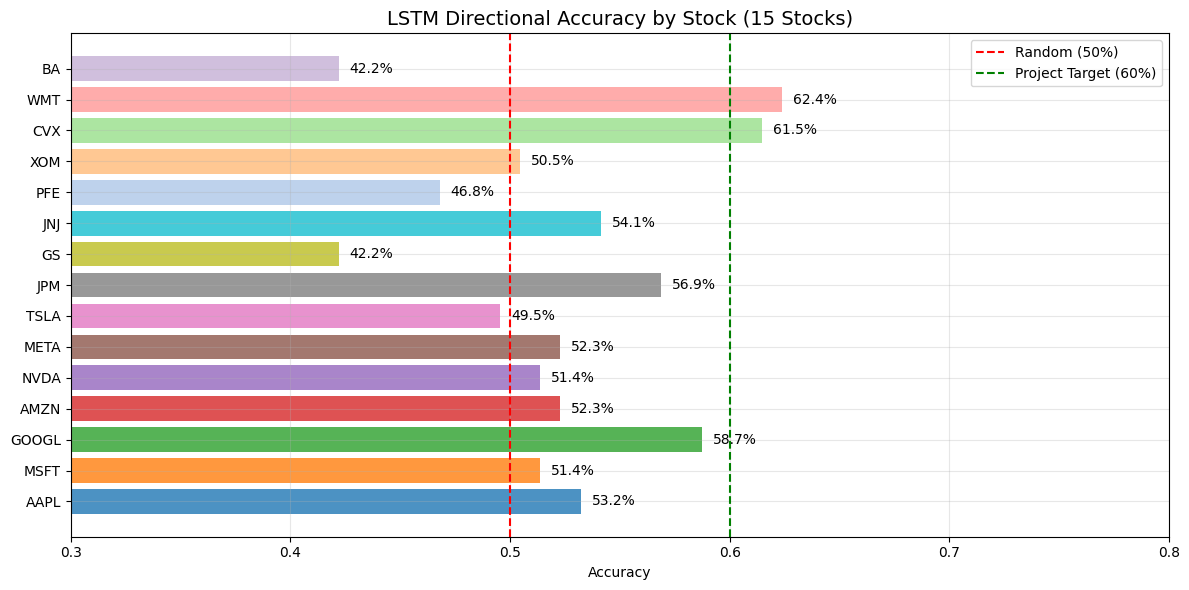

Saved: ../../data/results/lstm_15stocks_accuracy_bar.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
accs = [all_metrics[t]['Directional Accuracy'] for t in TICKERS]
bars = ax.barh(TICKERS, accs, color=[COLORS[t] for t in TICKERS], alpha=0.8)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Random (50%)')
ax.axvline(x=0.6, color='green', linestyle='--', linewidth=1.5, label='Project Target (60%)')
for i, v in enumerate(accs):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=10)
ax.set_title('LSTM Directional Accuracy by Stock (15 Stocks)', fontsize=14)
ax.set_xlabel('Accuracy')
ax.set_xlim(0.3, 0.8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_15stocks_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_15stocks_accuracy_bar.png')

## 10. Confusion Matrices

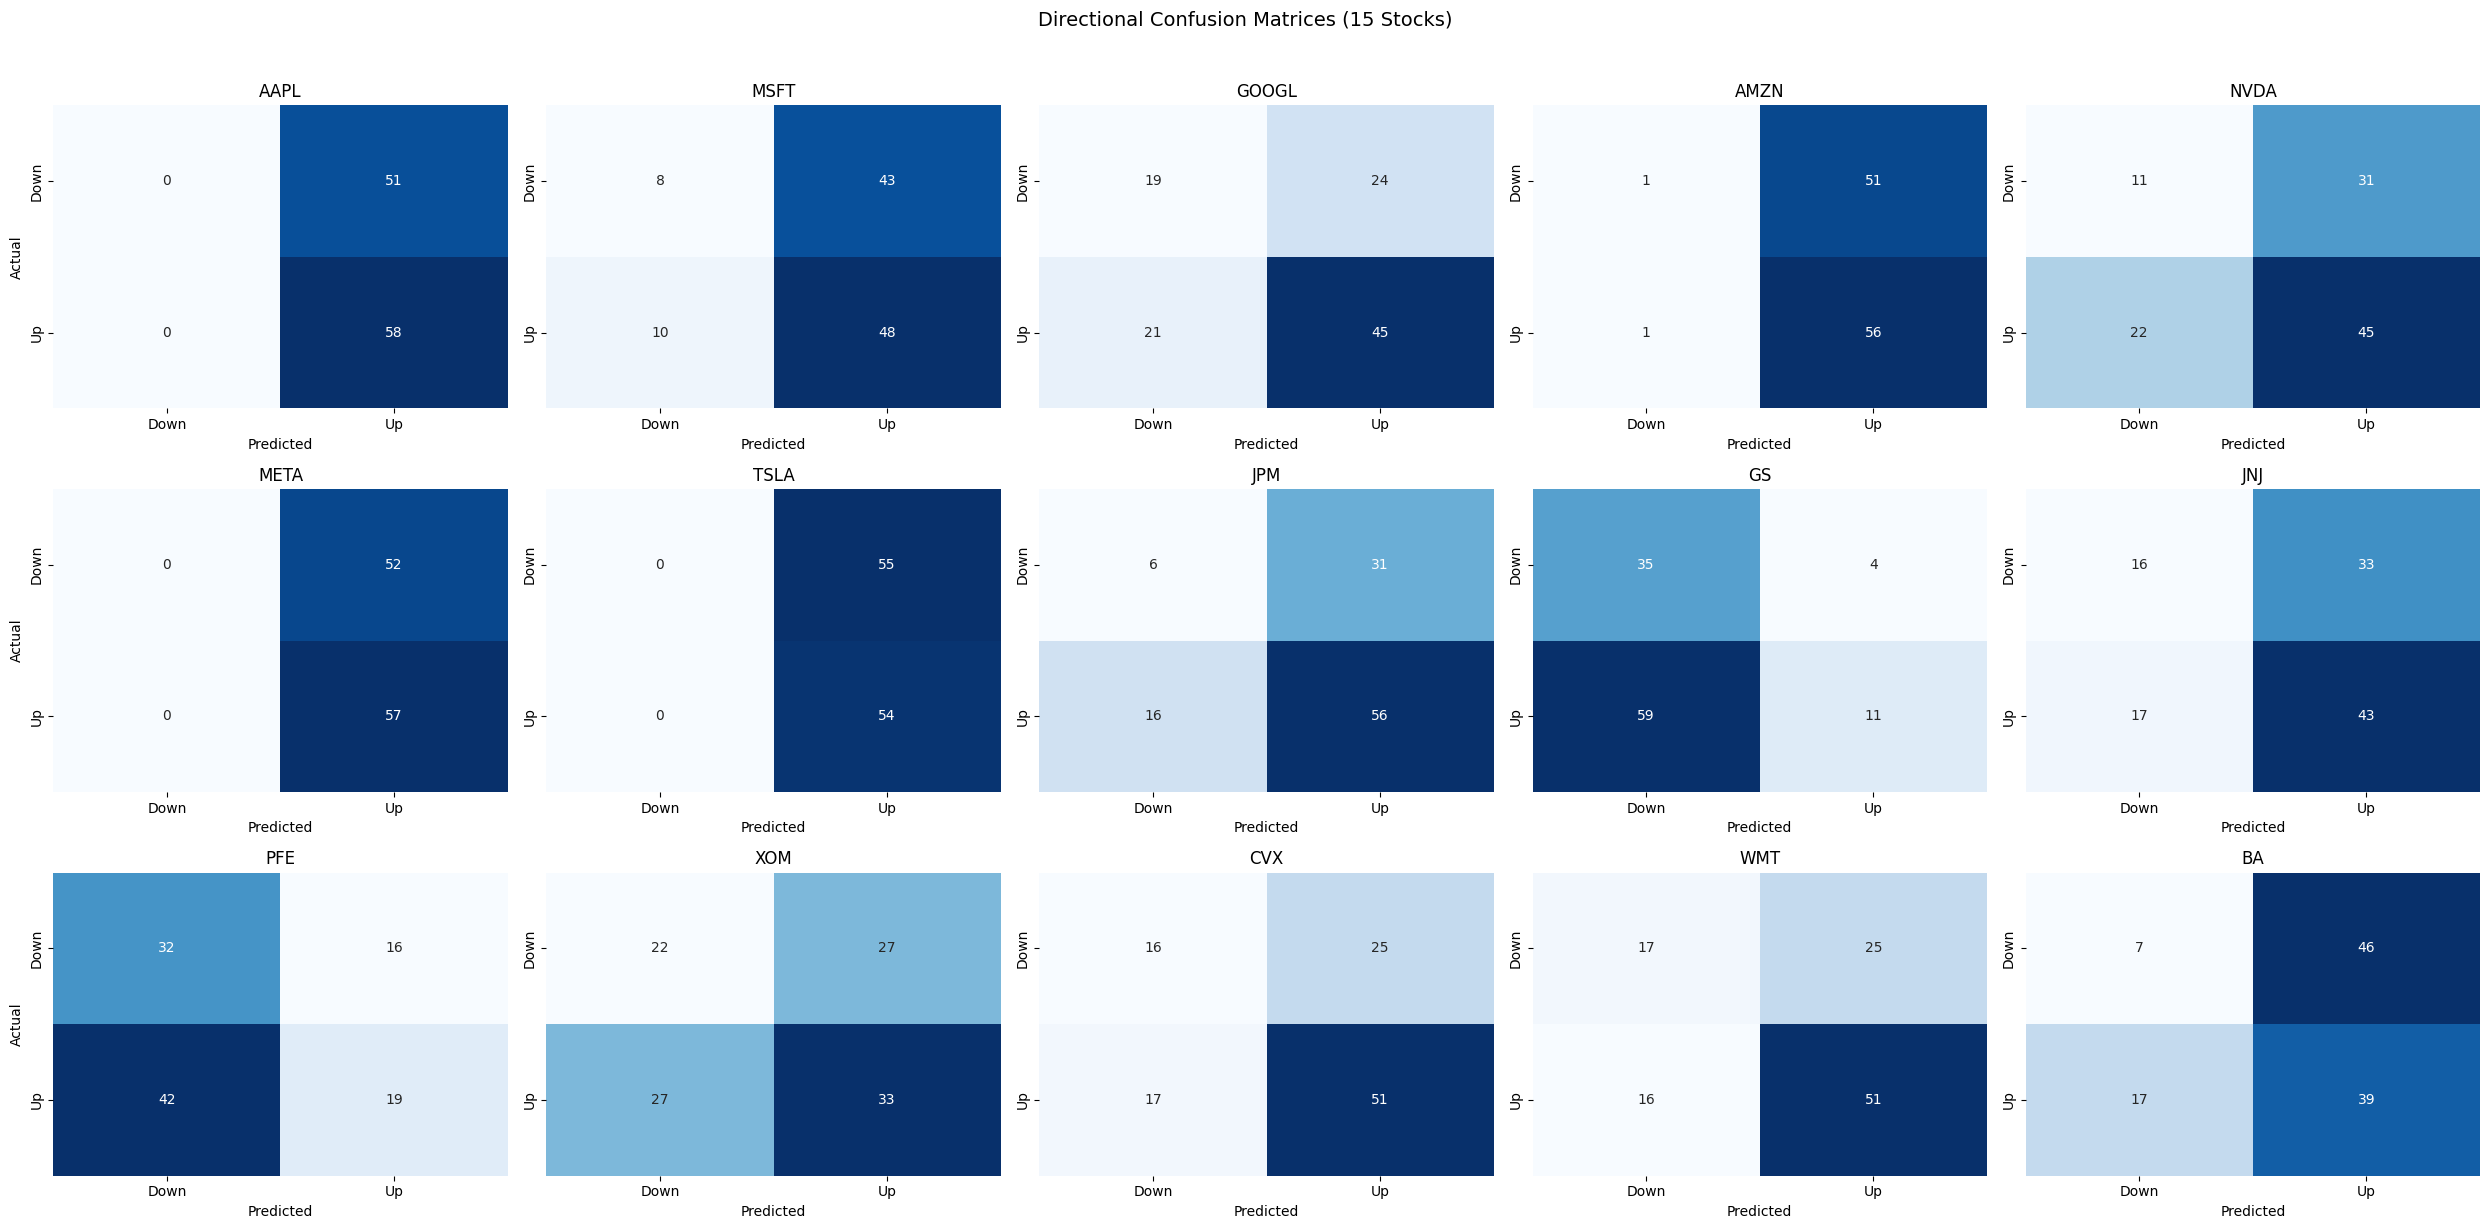

In [10]:
n_cols = 5
n_rows = (len(TICKERS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker]
    cm = confusion_matrix(td['Actual_Direction'], td['Pred_Direction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], cbar=False)
    axes[i].set_title(f'{ticker}', fontsize=12)
    axes[i].set_xlabel('Predicted')
    if i % n_cols == 0:
        axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Directional Confusion Matrices (15 Stocks)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_15stocks_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Summary

In [11]:
with open(f'{OUT_DIR}/lstm_15stocks_summary.txt', 'w') as f:
    f.write('LSTM 15-Stock Model Summary\n')
    f.write('=' * 50 + '\n\n')
    f.write('Approach: Binary Classification (Up vs Down)\n')
    f.write('Architecture: LSTM(64) > Dropout(0.2) > LSTM(32) > Dropout(0.2) > Dense(16, ReLU) > BatchNorm > Dense(1, sigmoid)\n')
    f.write(f'Input: {SEQUENCE_LENGTH} weeks x {len(feature_cols)} features\n')
    f.write(f'Stocks: {len(TICKERS)}\n')
    f.write(f'Optimizer: Adam (lr=0.001) | Loss: Binary Crossentropy\n\n')
    f.write('Per-Stock Metrics:\n')
    f.write(metrics_df.to_string())
    f.write(f'\n\nOverall F1: {overall_f1:.4f}\n')
    f.write(f'Overall Ranking Accuracy: {overall_rank_acc:.1%} (random: {1/n:.1%})\n')
    f.write(f'Top-1 Accuracy: {top1_acc:.1%} (random: {1/n:.1%})\n')
    f.write(f'Top-2 Accuracy: {top2_acc:.1%} (random: {2/n:.1%})\n')

print(f'Saved: {OUT_DIR}/lstm_15stocks_summary.txt')
print('\nLSTM 15-stock modeling complete!')

Saved: ../../data/results/lstm_15stocks_summary.txt

LSTM 15-stock modeling complete!
